Name = Arav Mahind

Roll = 24102A2008

Branch-Div = CMPN-A

Subject = R Programming

Lab = 05

Install & Load Library

In [5]:
system("apt-get update -qq && apt-get install -y -qq r-cran-igraph")

In [6]:
library(igraph)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




Create Graphs

In [7]:
# Undirected graph with 7 nodes
g <- make_graph(c(1, 2, 2, 3, 3, 4, 4, 1), directed = FALSE, n = 7)

# Directed graph with labeled nodes
g1 <- make_graph(c("Amy", "Ram", "Ram", "Li", "Li", "Amy",
                   "Amy", "Li", "Kate", "Li"),
                 directed = TRUE)

print(g1)

IGRAPH d957b13 DN-- 4 5 -- 
+ attr: name (v/c)
+ edges from d957b13 (vertex names):
[1] Amy ->Ram Ram ->Li  Li  ->Amy Amy ->Li  Kate->Li 


Calculate Centrality & Properties

In [8]:
print("--- Degrees ---")
degree(g1, mode = 'all')
degree(g1, mode = 'in')
degree(g1, mode = 'out')

print("--- Network Properties ---")
diameter(g1, directed = FALSE, weights = NA)
edge_density(g1, loops = FALSE)

print("--- Reciprocity ---")
reciprocity(g1)

print("--- Centrality ---")
closeness(g1, mode = 'all', weights = NA)
betweenness(g1, directed = TRUE, weights = NA)
edge_betweenness(g1, directed = TRUE, weights = NA)

[1] "--- Degrees ---"


Amy  Ram   Li Kate 
   3    2    4    1

Amy  Ram   Li Kate 
   1    1    3    0

Amy  Ram   Li Kate 
   2    1    1    1

[1] "--- Network Properties ---"


...

[1] 0.4

[1] "--- Centrality ---"


Amy       Ram        Li      Kate 
0.2500000 0.2500000 0.3333333 0.2000000

Amy  Ram   Li Kate 
   2    0    3    0

[1] 3 2 5 1 3

Import Dataset

In [9]:
data <- read.csv('https://raw.githubusercontent.com/bkrai/R-files-from-YouTube/main/networkdata.csv', header = TRUE)

y <- data.frame(data$first, data$second)
head(y)

,data.first,data.second
,<chr>,<chr>
1,AA,DD
2,AB,DD
3,AF,BA
4,DD,DA
5,CD,EC
6,DD,CE


Degree Histogram

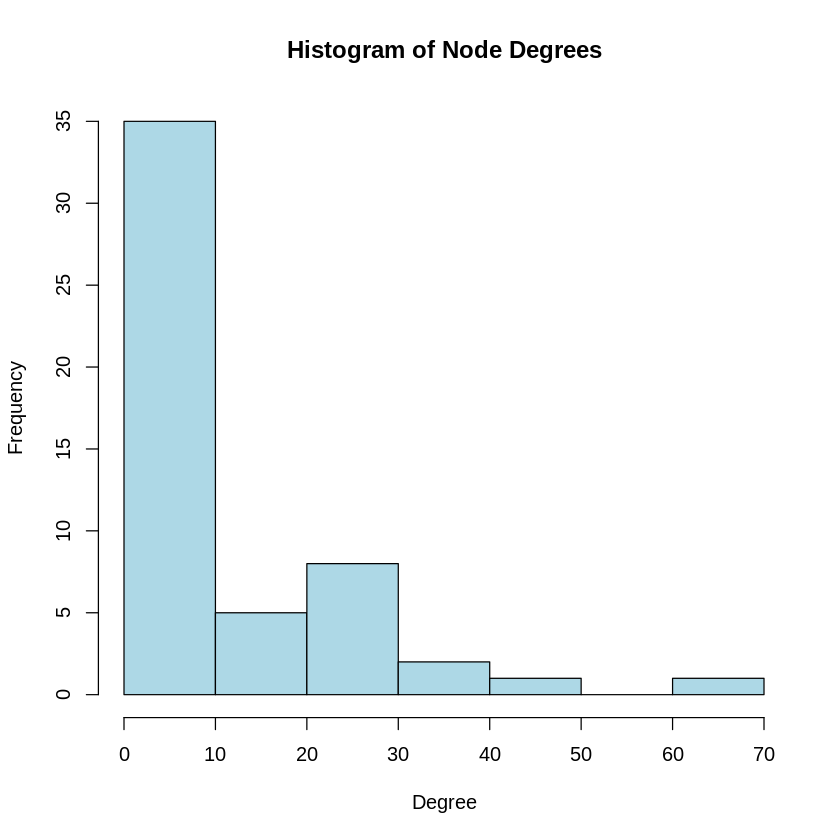

In [10]:
# Create network
net <- graph_from_data_frame(y, directed = TRUE)

# Assign names to labels and calculate node degrees
V(net)$label <- V(net)$name
V(net)$degree <- degree(net)

# Plot a histogram of node degrees
hist(V(net)$degree, main = "Histogram of Node Degrees", xlab = "Degree", col = "lightblue")

Network Plotting

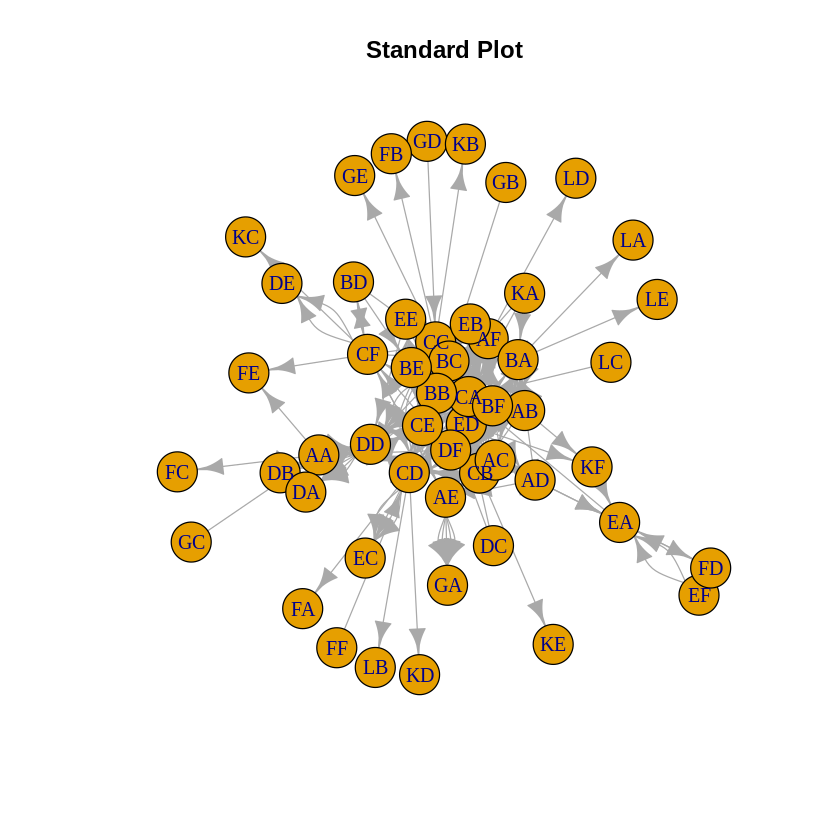

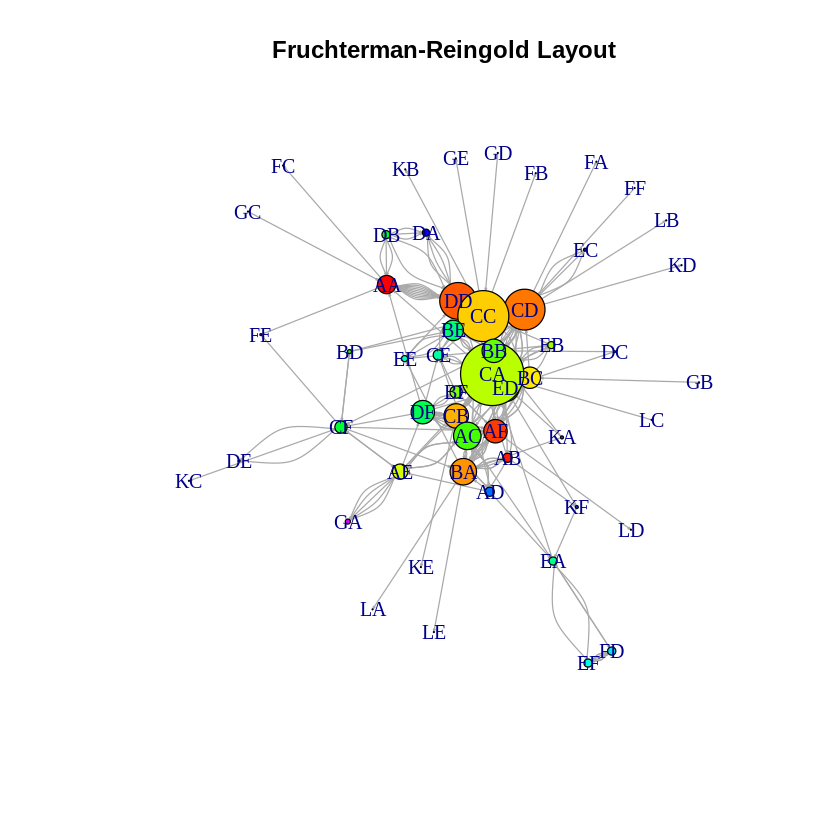

In [11]:
plot(net, main = "Standard Plot")

plot(net,
     vertex.color = rainbow(52),
     vertex.size = V(net)$degree * 0.4,
     edge.arrow.size = 0.1,
     layout = layout_with_fr,
     main = "Fruchterman-Reingold Layout")

Hubs and Authorities Plot

Warning message:
“`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead.”
Warning message:
“`authority_score()` was deprecated in igraph 2.1.0.
ℹ Please use `hits_scores()` instead.”


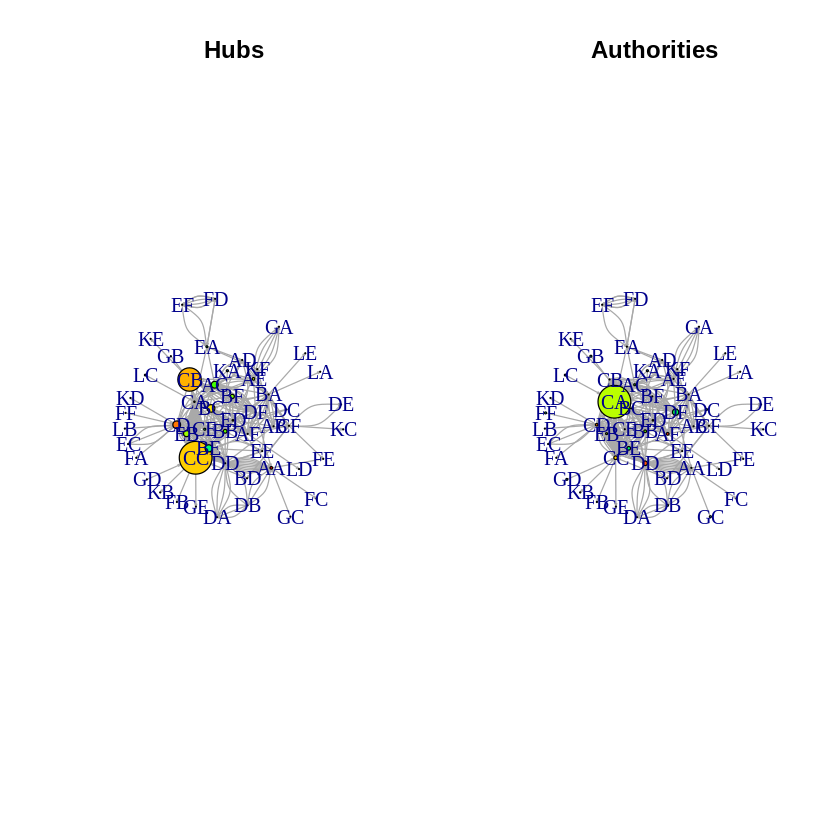

In [12]:
# Calculate scores
hs <- hub_score(net)$vector
as <- authority_score(net)$vector

par(mfrow = c(1, 2))
set.seed(123)

# Plot Hubs using Kamada-Kawai layout
plot(net,
     vertex.size = hs * 30,
     main = 'Hubs',
     vertex.color = rainbow(52),
     edge.arrow.size = 0.1,
     layout = layout_with_kk)

# Plot Authorities using Kamada-Kawai layout
plot(net,
     vertex.size = as * 30,
     main = 'Authorities',
     vertex.color = rainbow(52),
     edge.arrow.size = 0.1,
     layout = layout_with_kk)

# Reset plotting area to default
par(mfrow = c(1, 1))

In this experiment, we learned how to analyze social networks in R using the igraph package. We created both directed and undirected graphs and calculated key network metrics like degree, diameter, density, and centrality to find the most important nodes. Finally, by loading a real dataset, we visualized the network using different layouts and identified key connectors using Hub and Authority scores.